# Use MIOFlow to infer trajectories on PHATE space

Prerequisites:
- You have preprocessed your data and saved a mioflow DataFrame [notebook: 3-time-pseudotime]: 
    - rows are cells
    - columns are embeddings dimensions
    - "samples" are the discrete time labels


In this notebook, we will:
- Run MIOFlow on our PHATE space to infer trajectories

## 1. Importing MIOFlow and defining data paths

In [ ]:
from MIOFlow.utils import generate_steps, set_seeds, config_criterion
# from MIOFlow.models import make_model, Autoencoder

import torch
import torch.nn as nn
from torch.nn  import functional as F 
from torchdiffeq import odeint_adjoint as odeint
import torchsde
import itertools
from MIOFlow.plots import plot_comparision, plot_losses
from MIOFlow.train import train_ae, training_regimen

from MIOFlow.geo import setup_distance
from MIOFlow.exp import setup_exp
from MIOFlow.eval import generate_plot_data

import os
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'

import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
PROCESSED_DATA_DIR = os.path.join('../../data', 'processed')
RESULTS_DIR = os.path.join('../../results')

data_name = 'scRNAseq'
SAVE_PATH = os.path.join(RESULTS_DIR, data_name)


## 1. Retrieve the data and embedding normalization
First we retrieve the data.

Then, we will normalize the embeddings as a standard procedure to enable our network to learn better.

**Attention:** It is important to save the _std_ and _mean_ values. 

It is important to save the _std_ and _mean_ values because when decoding back using the `DimChanger`, we need to ensure that the outputs follow the distributions of the initial embeddings.

In [2]:
data = pd.read_csv(os.path.join(SAVE_PATH,'mioflow_data.csv'))
data.head(1)

,d1,d2,samples
0,-0.038221,-0.011244,0


In [3]:
# Get embedding columns dynamically
embed_cols = [col for col in data.columns if col.startswith('d') and col[1:].isdigit()] # Retrieve the columns that start with a d
embedding = data[embed_cols].values
embedding

array([[-0.03822131, -0.01124365],
       [-0.03246956, -0.00192726],
       [-0.02484374,  0.00668368],
       ...,
       [ 0.02337179, -0.00390573],
       [ 0.02538955, -0.00400225],
       [ 0.02025754, -0.0015742 ]])

### Normalizing the data

In [4]:
# Normalize across all dimensions properly
mean_vals = np.mean(embedding, axis=0)
std_vals = np.std(embedding, axis=0)
std_vals = np.where(std_vals == 0, 1, std_vals)  # Prevent division by zero
normalized = (embedding - mean_vals) / std_vals
# Normalized that is going to be used to train the network
normalized

array([[-2.22558755, -0.93082869],
       [-1.89790302, -0.17332517],
       [-1.46345042,  0.52681849],
       ...,
       [ 1.28344866, -0.33419182],
       [ 1.39840319, -0.34203967],
       [ 1.10602621, -0.14461822]])

In [5]:
# We create the dataframe with the normalized data and the samples
df = pd.DataFrame(normalized, columns=[f'd{i+1}' for i in range(normalized.shape[1])])
df['samples'] = data['samples']
df.head(1)

,d1,d2,samples
0,-2.225588,-0.930829,0


In [6]:
# Retrieve the number of samples that are in the less representative class.
min_count = df['samples'].value_counts().min()

### [Optional] We can resample our dataset to take an equal number of samples across the time_labels.

Only uncomment the following lines if you want to resample the dataset!

In [7]:
# # Retrieve the number of samples that are in the less representative class.
# min_count = df['samples'].value_counts().min()
# # Subsample the dataset to keep the same number of samples across all possible samples
# df = df.groupby('samples').apply(lambda x: x.sample(min_count)).reset_index(drop=True)

### Let's visualize what will be our input data using PHATE

If your data looks right, and we can see a path for the trajectories to follow, we can move on to training the MIOFlow algorithm

<Axes: xlabel='d1', ylabel='d2'>

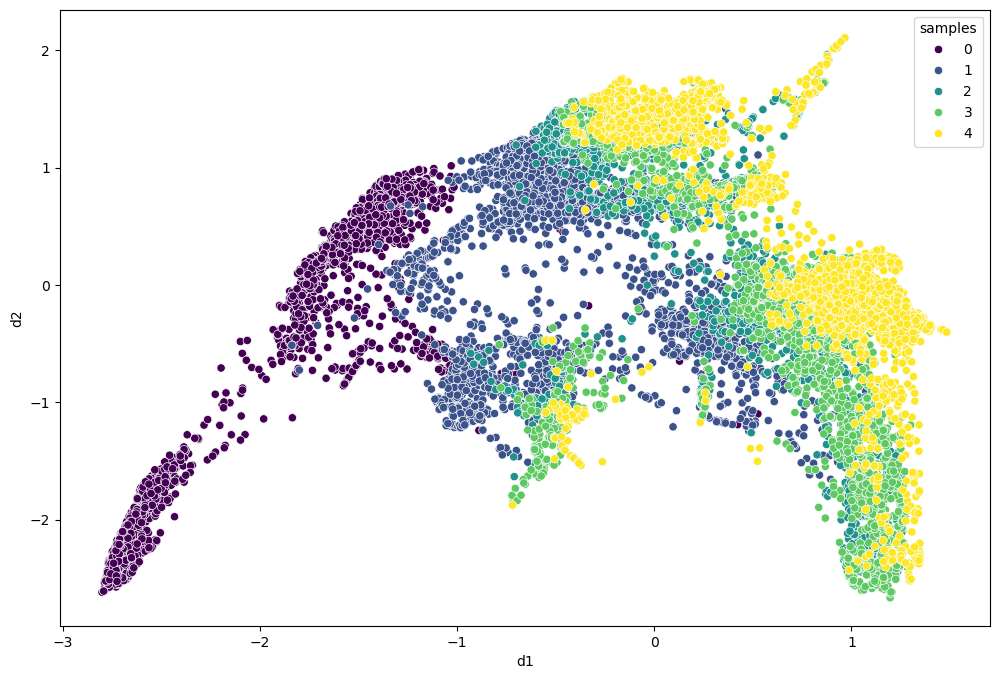

In [8]:
fig = plt.figure(figsize=(12, 8))
sns.scatterplot(data=df, x='d1', y='d2', hue='samples', palette='viridis')

# Training the MIOFlow Model

A lot of this initial cells will be just setting up configurations to run the MIOFlow algorithm.

In [9]:
# Import torch library and verify if GPUs are available to be used.
import torch
set_seeds(0)
use_cuda = torch.cuda.is_available()

In [ ]:
class ToyODE(nn.Module):
    """ 
    ODE derivative network
    
    feature_dims (int) default '5': dimension of the inputs, either in ambient space or embedded space.
    layer (list of int) defaulf ''[64]'': the hidden layers of the network.
    activation (torch.nn) default '"ReLU"': activation function applied in between layers.
    scales (NoneType|list of float) default 'None': the initial scale for the noise in the trajectories. One scale per bin, add more if using an adaptative ODE solver.
    n_aug (int) default '1': number of added dimensions to the input of the network. Total dimensions are features_dim + 1 (time) + n_aug. 
    
    Method
    forward (Callable)
        forward pass of the ODE derivative network.
        Parameters:
        t (torch.tensor): time of the evaluation.
        x (torch.tensor): position of the evalutation.
        Return:
        derivative at time t and position x.   
    """
    def __init__(
        self, 
        feature_dims=5,
        layers=[64],
        activation='ReLU',
        scales=None,
        n_aug=2,
        momentum_beta = 0.0,
        condition_dims=0, # TODO: make it a dict instead of assuming first!
    ):
        super(ToyODE, self).__init__()
        steps = [feature_dims+1+n_aug, *layers, feature_dims]
        pairs = zip(steps, steps[1:])
        self.condition_dim = condition_dims # TODO: make it a dict instead of assuming first!
        chain = list(itertools.chain(*list(zip(
            map(lambda e: nn.Linear(*e), pairs), 
            itertools.repeat(getattr(nn, activation)())
        ))))[:-1]

        self.chain = chain
        self.seq = (nn.Sequential(*chain))
        # self.initialize_final_layer()

        self.alpha = nn.Parameter(torch.tensor(scales, requires_grad=True).float()) if scales is not None else None
        self.n_aug = n_aug  

        self.momentum_beta = momentum_beta
        self.previous_v = None

    # def initialize_final_layer(self):
    #     # For the final layer of fc_g, use Xavier uniform initialization for weights
    #     # and set the bias to a small positive constant (e.g., 0.1)
    #     final_layer = self.seq[-1]
    #     if isinstance(final_layer, nn.Linear):
    #         nn.init.xavier_uniform_(final_layer.weight)
    #         nn.init.constant_(final_layer.bias, 0.1)    
        
    def forward(self, t, x): #NOTE the forward pass when we use torchdiffeq must be forward(self,t,x)
        zero = torch.tensor([0]).cuda() if x.is_cuda else torch.tensor([0])
        zeros = zero.repeat(x.size()[0],self.n_aug)
        time = t.repeat(x.size()[0],1)
        aug = torch.cat((x,time,zeros),dim=1)
        dxdt = self.seq(aug)
        if self.alpha is not None:
            z = torch.randn(x.size(),requires_grad=False).cuda() if x.is_cuda else torch.randn(x.size(),requires_grad=False)
            dxdt = dxdt + z*self.alpha[int(t-1)]

        if self.momentum_beta > 0.0:
            if self.previous_v is None or self.previous_v.shape[0] != x.shape[0]:
                self.previous_v = torch.zeros_like(dxdt)

            dxdt = self.momentum_beta * self.previous_v + (1 - self.momentum_beta) * dxdt
            self.previous_v = dxdt.detach()
        return dxdt

In [ ]:
class ToyModel(nn.Module):
    """ 
    Neural ODE
        func (nn.Module): The network modeling the derivative.
        method (str) defaulf '"rk4"': any methods from torchdiffeq.
        rtol (NoneType | float): the relative tolerance of the ODE solver.
        atol (NoneType | float): the absolute tolerance. of the ODE solver.
        use_norm (bool): if True keeps the norm of func.
        norm (list of torch.tensor): the norm of the derivative.
        
        Method
        forward (Callable)
            x (torch.tensor): the initial sample
            t (torch.tensor) time points where we suppose x is from t[0]
            return the last sample or the whole seq.      
    """
    
    def __init__(self, func, method='rk4', rtol=None, atol=None, use_norm=False):
        super(ToyModel, self).__init__()        
        self.func = func
        self.method = method
        self.rtol=rtol
        self.atol=atol
        self.use_norm = use_norm
        self.norm=[]

    def forward(self, x, t, return_whole_sequence=False):

        if self.use_norm:
            for time in t: 
                self.norm.append(torch.linalg.norm(self.func(time,x)).pow(2))
        if self.atol is None and self.rtol is None:
            x = odeint(self.func,x ,t, method=self.method)
        elif self.atol is not None and self.rtol is None:
            x = odeint(self.func,x ,t, method=self.method, atol=self.atol)
        elif self.atol is None and self.rtol is not None:
            x = odeint(self.func,x ,t, method=self.method, rtol=self.rtol)
        else: 
            x = odeint(self.func,x ,t, method=self.method, atol=self.atol, rtol=self.rtol)          
       
        x = x[-1] if not return_whole_sequence else x
        return x

    def train(self, mode=True):
        # reset the norm
        super().train(mode)
        self.norm = []

    def eval(self):
        super().eval()
        self.norm = []

In [ ]:
def make_model(
    feature_dims=5,
    layers=[64],
    output_dims=5,
    activation='ReLU',
    which='ode',
    method='rk4',
    rtol=None,
    atol=None,
    scales=None,
    n_aug=2,
    noise_type='diagonal', sde_type='ito',
    adjoint_method=None,
    use_norm=False,
    use_cuda=False,
    in_features=2, out_features=2, gunc=None,
    n_conditions=0,
    momentum_beta = 0.0,
):
    """
    Creates the 'ode' model or 'sde' model or the Geodesic Autoencoder. 
    See the parameters of the respective classes.
    """
    if which == 'ode' and n_conditions == 0:
        ode = ToyODE(feature_dims, layers, activation,scales,n_aug)
        model = ToyModel(ode,method,rtol, atol, use_norm=use_norm)
    if use_cuda:
        model.cuda()
    return model 

In [ ]:
def training_regimen(
    n_local_epochs, n_epochs, n_post_local_epochs,
    exp_dir, 

    # BEGIN: train params
    model, df, groups, optimizer, n_batches=20, 
    criterion=MMD_loss(), use_cuda=False,


    hold_one_out=False, hold_out='random', 
    hinge_value=0.01, use_density_loss=True, 

    top_k = 5, lambda_density = 1.0, 
    autoencoder=None, use_emb=True, use_gae=False, 
    sample_size=(100, ), 
    sample_with_replacement=False, 
    logger=None, 
    add_noise=False, noise_scale=0.1, use_gaussian=True,  
    use_penalty=False, lambda_energy=1.0,
    # END: train params

    steps=None, plot_every=None,
    n_points=100, n_trajectories=100, n_bins=100, 
    local_losses=None, batch_losses=None, globe_losses=None,
    reverse_schema=True, reverse_n=4,
    n_conditions:int = 0, # TODO deprecated! now will extract from model.func.condition_dim!
    lambda_cond:float = 0.0,
    growth_rate_model=None,
    lrs=None,
    ot_lambda_global=None,
    ot_lambda_local=None,
    lambda_energy_local=None,
    lambda_energy_global=None
):
    if lrs is not None:
        assert len(lrs) == 3
    recon = use_gae and not use_emb
    if steps is None:
        steps = generate_steps(groups)
        
    if local_losses is None:
        if hold_one_out and hold_out in groups:
            groups_ho = [g for g in groups if g != hold_out]
            local_losses = {f'{t0}:{t1}':[] for (t0, t1) in generate_steps(groups_ho) if hold_out not in [t0, t1]}
            if reverse_schema:
                local_losses = {
                    **local_losses, 
                    **{f'{t0}:{t1}':[] for (t0, t1) in generate_steps(groups_ho[::-1]) if hold_out not in [t0, t1]}
                }
        else:
            local_losses = {f'{t0}:{t1}':[] for (t0, t1) in generate_steps(groups)}
            if reverse_schema:
                local_losses = {
                    **local_losses, 
                    **{f'{t0}:{t1}':[] for (t0, t1) in generate_steps(groups[::-1])}
                }
    if batch_losses is None:
        batch_losses = []
    if globe_losses is None:
        globe_losses = []
    
    reverse = False
    for epoch in tqdm(range(n_local_epochs), desc='Pretraining Epoch'):
        if lrs is not None:
            for param_group in optimizer.param_groups:
                param_group['lr'] = lrs[0]

        reverse = True if reverse_schema and epoch % reverse_n == 0 else False
        l_loss, b_loss, g_loss = train(
            model, df, groups, optimizer, n_batches, 
            criterion = criterion, use_cuda = use_cuda,
            local_loss=True, global_loss=False, apply_losses_in_time=True,
            hold_one_out=hold_one_out, hold_out=hold_out, 
            hinge_value=hinge_value,
            use_density_loss = use_density_loss,    
            top_k = top_k, lambda_density = lambda_density, 
            autoencoder = autoencoder, use_emb = use_emb, use_gae = use_gae, sample_size=sample_size, 
            sample_with_replacement=sample_with_replacement, logger=logger,
            add_noise=add_noise, noise_scale=noise_scale, use_gaussian=use_gaussian, 
            use_penalty=use_penalty, lambda_energy=lambda_energy, reverse=reverse,
            n_conditions=n_conditions, lambda_cond=lambda_cond, growth_rate_model=growth_rate_model,
            ot_lambda_global=ot_lambda_global, ot_lambda_local=ot_lambda_local,
            lambda_energy_local=lambda_energy_local, lambda_energy_global=lambda_energy_global
        )
        for k, v in l_loss.items():  
            local_losses[k].extend(v)
        batch_losses.extend(b_loss)
        globe_losses.extend(g_loss)
        if plot_every is not None and epoch % plot_every == 0:
            generated, trajectories = generate_plot_data(
                model, df, n_points, n_trajectories, n_bins, 
                sample_with_replacement=sample_with_replacement, use_cuda=use_cuda, 
                samples_key='samples', logger=logger,
                autoencoder=autoencoder, recon=recon
            )
            plot_comparision(
                df, generated, trajectories,
                palette = 'viridis', df_time_key='samples',
                save=True, path=exp_dir, 
                file=f'2d_comparision_local_{epoch}.png',
                x='d1', y='d2', z='d3', is_3d=False
            )

    for epoch in tqdm(range(n_epochs), desc='Epoch'):
        if lrs is not None:
            for param_group in optimizer.param_groups:
                param_group['lr'] = lrs[1]

        reverse = True if reverse_schema and epoch % reverse_n == 0 else False
        l_loss, b_loss, g_loss = train(
            model, df, groups, optimizer, n_batches, 
            criterion = criterion, use_cuda = use_cuda,
            local_loss=False, global_loss=True, apply_losses_in_time=True,
            hold_one_out=hold_one_out, hold_out=hold_out, 
            hinge_value=hinge_value,
            use_density_loss = use_density_loss,       
            top_k = top_k, lambda_density = lambda_density, 
            autoencoder = autoencoder, use_emb = use_emb, use_gae = use_gae, sample_size=sample_size, 
            sample_with_replacement=sample_with_replacement, logger=logger, 
            add_noise=add_noise, noise_scale=noise_scale, use_gaussian=use_gaussian,
            use_penalty=use_penalty, lambda_energy=lambda_energy, reverse=reverse,
            n_conditions=n_conditions, lambda_cond=lambda_cond, growth_rate_model=growth_rate_model,
            ot_lambda_global=ot_lambda_global, ot_lambda_local=ot_lambda_local,
            lambda_energy_local=lambda_energy_local, lambda_energy_global=lambda_energy_global
        )
        for k, v in l_loss.items():  
            local_losses[k].extend(v)
        batch_losses.extend(b_loss)
        globe_losses.extend(g_loss)
        if plot_every is not None and epoch % plot_every == 0:
            generated, trajectories = generate_plot_data(
                model, df, n_points, n_trajectories, n_bins, 
                sample_with_replacement=sample_with_replacement, use_cuda=use_cuda, 
                samples_key='samples', logger=logger,
                autoencoder=autoencoder, recon=recon
            )
            plot_comparision(
                df, generated, trajectories,
                palette = 'viridis', df_time_key='samples',
                save=True, path=exp_dir, 
                file=f'2d_comparision_local_{n_local_epochs}_global_{epoch}.png',
                x='d1', y='d2', z='d3', is_3d=False
            )
        
    for epoch in tqdm(range(n_post_local_epochs), desc='Posttraining Epoch'):
        if lrs is not None:
            for param_group in optimizer.param_groups:
                param_group['lr'] = lrs[2]
        reverse = True if reverse_schema and epoch % reverse_n == 0 else False

        l_loss, b_loss, g_loss = train(
            model, df, groups, optimizer, n_batches, 
            criterion = criterion, use_cuda = use_cuda,
            local_loss=True, global_loss=False, apply_losses_in_time=True,
            hold_one_out=hold_one_out, hold_out=hold_out, 
            hinge_value=hinge_value,
            use_density_loss = use_density_loss,       
            top_k = top_k, lambda_density = lambda_density,  
            autoencoder = autoencoder, use_emb = use_emb, use_gae = use_gae, sample_size=sample_size, 
            sample_with_replacement=sample_with_replacement, logger=logger, 
            add_noise=add_noise, noise_scale=noise_scale, use_gaussian=use_gaussian,
            use_penalty=use_penalty, lambda_energy=lambda_energy, reverse=reverse,
            n_conditions=n_conditions, lambda_cond=lambda_cond, growth_rate_model=growth_rate_model,
            ot_lambda_global=ot_lambda_global, ot_lambda_local=ot_lambda_local,
            lambda_energy_local=lambda_energy_local, lambda_energy_global=lambda_energy_global
        )
        for k, v in l_loss.items():  
            local_losses[k].extend(v)
        batch_losses.extend(b_loss)
        globe_losses.extend(g_loss)
        if plot_every is not None and epoch % plot_every == 0:
            generated, trajectories = generate_plot_data(
                model, df, n_points, n_trajectories, n_bins, 
                sample_with_replacement=sample_with_replacement, use_cuda=use_cuda, 
                samples_key='samples', logger=logger,
                autoencoder=autoencoder, recon=recon
            )
            plot_comparision(
                df, generated, trajectories,
                palette = 'viridis', df_time_key='samples',
                save=True, path=exp_dir, 
                file=f'2d_comparision_local_{n_local_epochs}_global_{n_epochs}_post_{epoch}.png',
                x='d1', y='d2', z='d3', is_3d=False
            )

    if reverse_schema:
        _temp = {}
        if hold_one_out:
            for (t0, t1) in generate_steps([g for g in groups if g != hold_out]):
                a = f'{t0}:{t1}'
                b = f'{t1}:{t0}'
                _temp[a] = []
                for i, value in enumerate(local_losses[a]):

                    if i % reverse_n == 0:
                        _temp[a].append(local_losses[b].pop(0))
                        _temp[a].append(value)
                    else:
                        _temp[a].append(value)
            local_losses = _temp
        else:
            for (t0, t1) in generate_steps(groups):
                a = f'{t0}:{t1}'
                b = f'{t1}:{t0}'
                _temp[a] = []
                for i, value in enumerate(local_losses[a]):

                    if i % reverse_n == 0:
                        _temp[a].append(local_losses[b].pop(0))
                        _temp[a].append(value)
                    else:
                        _temp[a].append(value)
            local_losses = _temp



    if plot_every is not None:
        plot_losses(
            local_losses, batch_losses, globe_losses, 
            save=True, path=exp_dir, 
            file=f'losses_l{n_local_epochs}_e{n_epochs}_ple{n_post_local_epochs}.png'
        )

    return local_losses, batch_losses, globe_losses

In [10]:
# Here we create the model using the MIOFlow library

model = make_model(
    feature_dims = (len(df.columns) - 1),# The dimensions in the input space, it is columns - 1 because we assume one column is equal to "samples"., 
    layers = [16,32,16], # Can change but we never really do, mostly depends on the dataset.
    activation='CELU',
    scales=None, #sde_scales
    use_cuda=use_cuda,
)

print(model)

# Bookkeeping variables
batch_losses = []
globe_losses = []
local_losses = []

start_time = time.time()
local_losses, batch_losses, globe_losses = training_regimen(

    # local, global, local train structure
    n_local_epochs=40, 
    n_epochs=40, 
    n_post_local_epochs=0,
    
    # where results are stored
    exp_dir=SAVE_PATH, 

    # BEGIN: train params
    model=model, 
    df=df, 
    groups=sorted(df.samples.unique()), # Sorted list of the samples (the time bins)


    optimizer=torch.optim.AdamW(model.parameters()), 
    criterion=config_criterion('ot'), 
    use_cuda=use_cuda,

    hold_one_out=False, # True if we want to holdout (or skip) one timepoint during training. Can test the accuracy of the trajectories on unseen data.

    use_density_loss=True, # Density loss knn
    lambda_density=20,# Weight of density (not percentage of total loss)

    autoencoder=None, use_emb=False, use_gae=False, # This are used only if we are going to use the GeodesicAutoencoder (not in single-cell data)
    sample_size=(min(min_count, 100), ), # Basically "batch size"
    logger=None,

    reverse_schema=True,  # Using the reverse trajectories to train
    reverse_n=2,
    # END: train params

    plot_every=5,

    n_points=min(min_count, 100), # use 100 "batch_size" or if have lessa samples, reduce the batch size
    n_trajectories=min(min_count, 100), # use 100 "batch_size" or if have lessa samples, reduce the batch size
    n_bins=100 # TODO: define

)
run_time = time.time() - start_time

ToyModel(
  (func): ToyODE(
    (seq): Sequential(
      (0): Linear(in_features=5, out_features=16, bias=True)
      (1): CELU(alpha=1.0)
      (2): Linear(in_features=16, out_features=32, bias=True)
      (3): CELU(alpha=1.0)
      (4): Linear(in_features=32, out_features=16, bias=True)
      (5): CELU(alpha=1.0)
      (6): Linear(in_features=16, out_features=2, bias=True)
    )
  )
)


Pretraining Epoch:   0%|          | 0/40 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

Train loss: 6.7419


/Users/joaofelipe/miniconda3/envs/omics-toolbox/lib/python3.10/site-packages/MIOFlow/plots.py:216: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(frameon=False)


...

  0%|          | 0/20 [00:00<?, ?it/s]

Train loss: 6.33405


  0%|          | 0/20 [00:00<?, ?it/s]

Train loss: 6.15484


Posttraining Epoch: 0it [00:00, ?it/s]

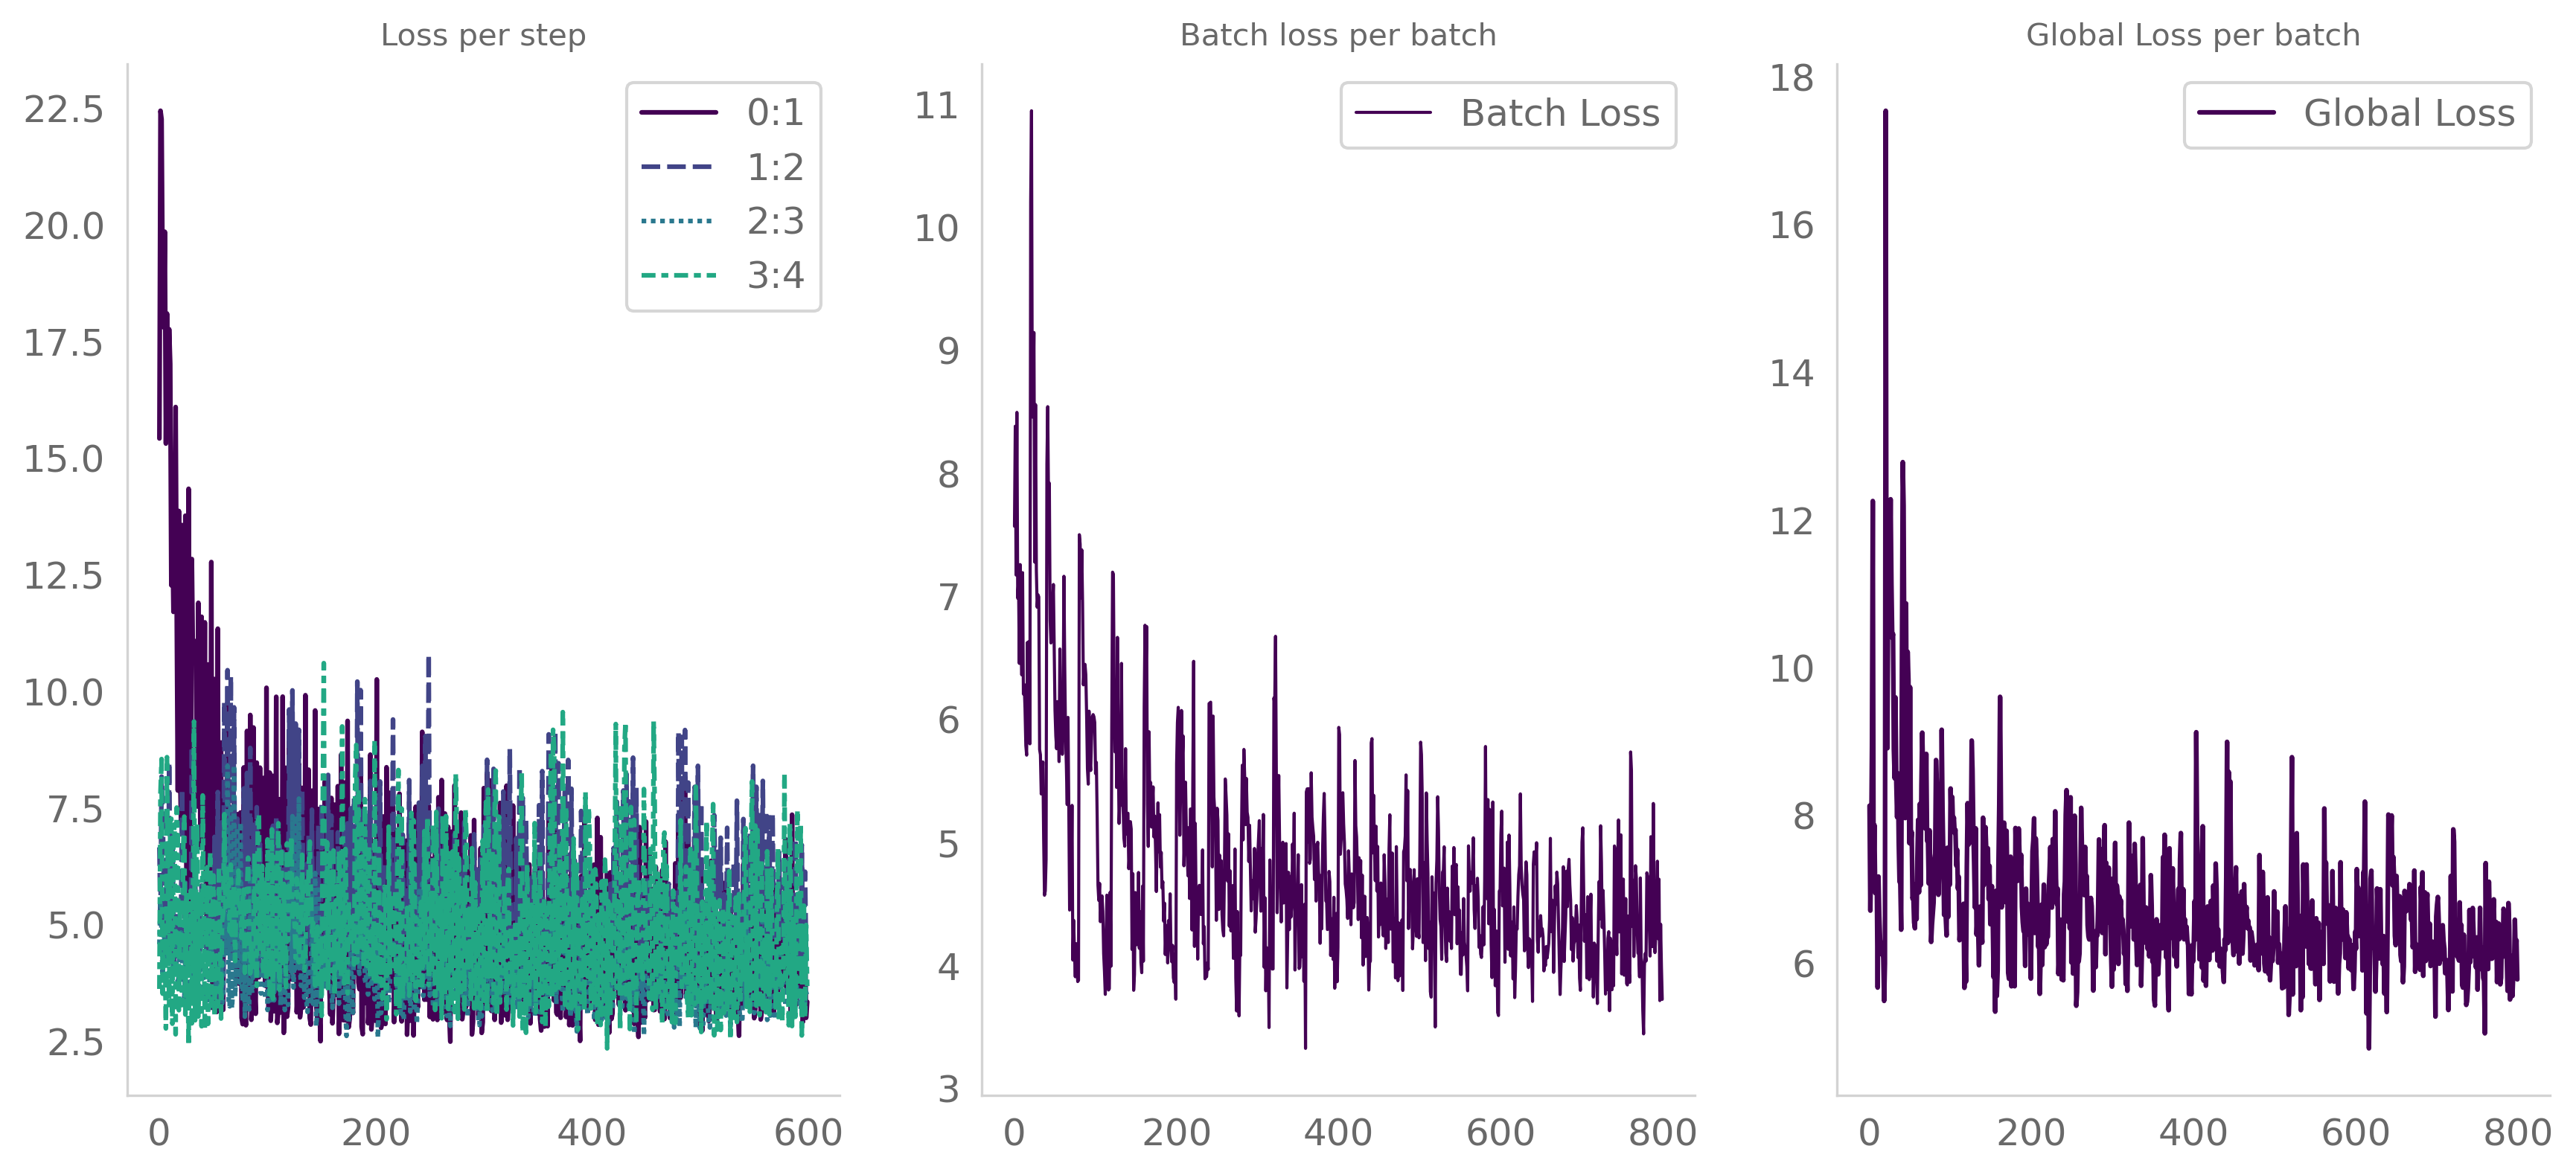

In [16]:
plot_losses(
    local_losses, 
    batch_losses, 
    globe_losses, 
    save=True, 
    path=SAVE_PATH, 
    file='losses.png'
)

In [18]:
generated, trajectoriespts = generate_plot_data(
    model, 
    df, 
    n_points=100, 
    n_trajectories=100, 
    n_bins=100, 
    use_cuda=use_cuda, 
    samples_key='samples', 
    logger=None,
    autoencoder=None, 
    recon=None
)

## Visualizing the MIOFlow Outputs and saving

In [19]:
trajectoriespts = trajectoriespts * std_vals + mean_vals
generated = generated * std_vals + mean_vals
true_data = df[[f'd{i}' for i in range(1, len(df.columns))]] * std_vals + mean_vals

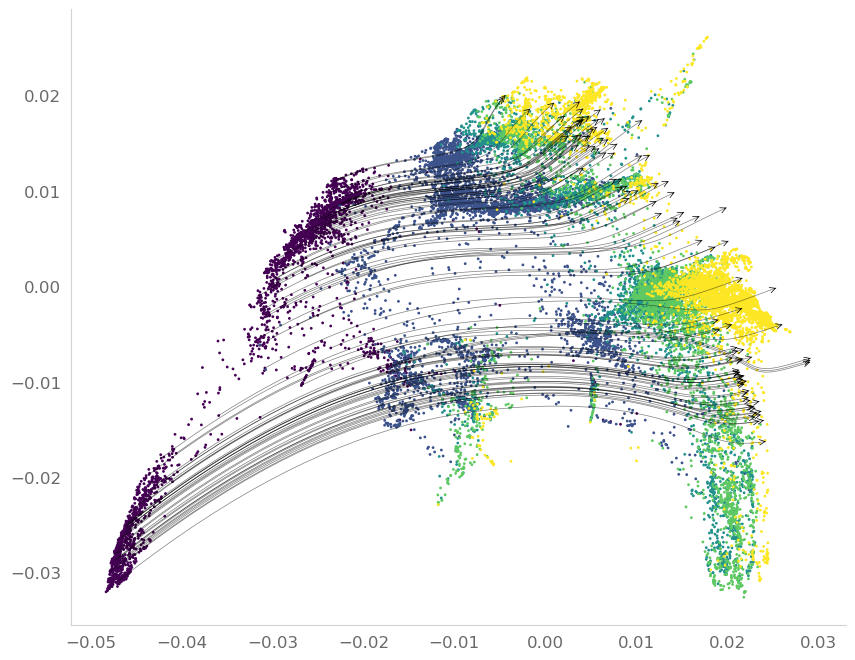

In [21]:
fig = plt.figure(figsize=(10, 8))
plt.scatter(true_data.values[:, 0], true_data.values[:, 1], c=df['samples'].values, cmap='viridis', s=1)
for i,traj in enumerate(np.transpose(trajectoriespts, axes=(1,0,2))):
    # widths = m_traj[:,i]
    plt.plot(traj[:, 0], traj[:, 1], alpha=.5, linewidth=.5, color='Black')
    plt.annotate('', xy=(traj[-1, 0], traj[-1, 1]), xytext=(traj[-2, 0], traj[-2, 1]),
                 arrowprops=dict(arrowstyle='->', color='Black', lw=.5, mutation_scale=10))

### Since our trajectories are looking good we can save them and let's visualize and interpret some of them in the next notebooks!

In [15]:
# saving the trajectories and generated points
# trajectories are the outputs for MIOFLow

np.save(os.path.join(SAVE_PATH,'trajectories.npy'), trajectoriespts)
np.save(os.path.join(SAVE_PATH,'generated.npy'), generated)
np.savez(os.path.join(SAVE_PATH, 'normalize.npz'), mean=mean_vals, std=std_vals)

#Pandas saving
true_data.to_csv(os.path.join(SAVE_PATH,'true_data.csv'))
df['samples'].to_csv(os.path.join(SAVE_PATH,'df_samples.csv'))

torch.save(model, SAVE_PATH + '/model.pt')
